In [1]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import warnings
import os

# Configure TensorFlow to use the legacy Keras interface
# This must run before importing tensorflow or unitvelo
os.environ["TF_USE_LEGACY_KERAS"] = "True"

import tensorflow
import unitvelo

2026-02-09 11:12:24.886421: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(Running UniTVelo 0.2.5.2)
2026-02-09 10:12:31


In [2]:
# Ignore deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

In [3]:
# Check if GPU is available
velo = unitvelo.config.Configuration()
velo.R2_ADJUST = True
velo.IROOT = None
velo.FIT_OPTION = '1'
if tensorflow.test.is_gpu_available():
    print("Using GPU")
    velo.GPU = 0
else:
    print("Using CPU")
    velo.GPU = -1

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
Using CPU


2026-02-09 11:12:31.795141: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# Read input file
working_directory = "RNA Sequencing Data/"
adata = scanpy.read_h5ad(working_directory+"/splice_counts_mm10.h5ad")

# Or read saved file for further analysis
# adata = scanpy.read_h5ad(working_directory+"/velocity_sdevelo.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day'
    var: 'ensemble_ids', 'gene_symbol'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


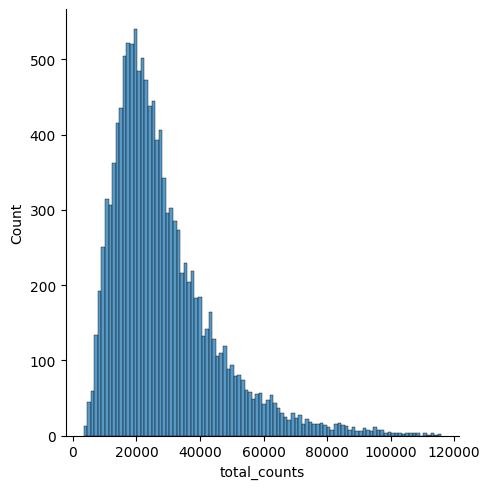

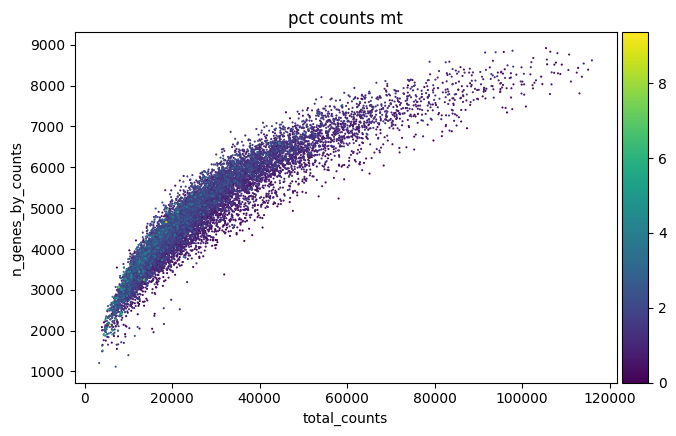

In [5]:
# Quality control

adata.var["mt"] = adata.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata, inplace=True, percent_top=[], log1p=False
)
histogram = seaborn.displot(adata.obs["total_counts"], bins=100, kde=False)
scatter = scanpy.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

View of AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


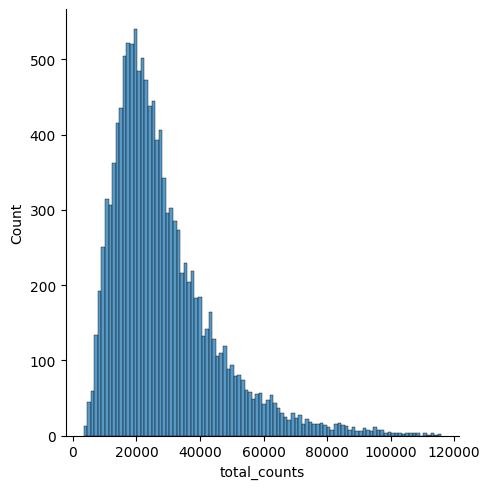

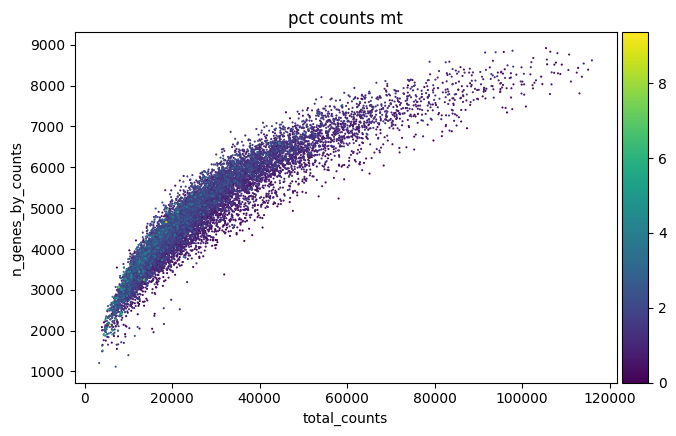

In [6]:
# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata.obs["n_genes_by_counts"] >= 200)*(adata.obs['total_counts'] <= 150000)*(adata.obs['pct_counts_mt'] < 10)
adata = adata[included_cells]
print(adata)
histogram = seaborn.displot(adata.obs["total_counts"], bins=100, kde=False)
scatter = scanpy.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

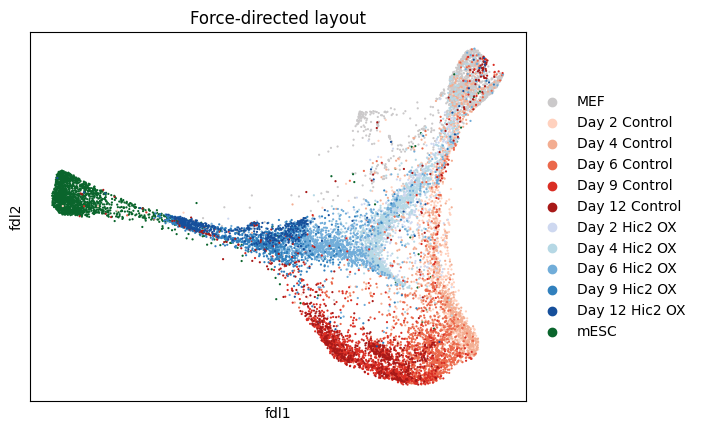

In [7]:
# Plot FDL

scanpy.pl.embedding(basis='fdl', adata=adata, color="sample", size=10, title="Force-directed layout")

In [8]:
# Train UniTVelo model
adata = unitvelo.run_model(adata, "sample", config_file=velo)

------> Manully Specified Parameters <------
GPU:	-1
------> Model Configuration Settings <------
N_TOP_GENES:	2000
LEARNING_RATE:	0.01
FIT_OPTION:	1
DENSITY:	SVD
REORDER_CELL:	Soft_Reorder
AGGREGATE_T:	True
R2_ADJUST:	True
GENE_PRIOR:	None
VGENES:	basic
IROOT:	None
--------------------------------------------

Current working dir is /home/avesta/m26_losu/hic2_masters_project.
Results will be stored in res folder
Filtered out 35658 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
Extracted 2000 highly variable genes.
Computing moments for 2000 genes with n_neighbors: 30 and n_pcs: 30


/home/avesta/m26_losu/miniconda3/envs/unitvelo/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/home/avesta/m26_losu/miniconda3/envs/unitvelo/lib/python3.12/site-packages/unitvelo/utils.py:610: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata,
/home/avesta/m26_losu/miniconda3/envs/unitvelo/lib/python3.12/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/avesta/m26_losu/miniconda3/envs/unitvelo/lib/python3.12/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automati

computing neighbors
    finished (0:00:30) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)

# of velocity genes 1407 (Criterion: positive regression coefficient between un/spliced counts)
# of velocity genes 1356 (Criterion: std of un/spliced reads should be moderate, w/o extreme values)
# of velocity genes 1340 (Criterion: genes have reads in more than 5% of total cells)
No GPU device has been detected. Switch to CPU mode.


Loss (Total): 2454974.042, (Spliced): 233722.794, (Unspliced): 2221251.248:   2%|▏         | 186/12000 [02:26<2:35:05,  1.27it/s]


KeyboardInterrupt: 

In [52]:
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'sample_colors', 'log1p', 'pca', 'neighbors'
    obsm: 'X_fdl', 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'sde_velocity', 'pred_u', 'pred_s'
    obsp: 'distances', 'connectivities'


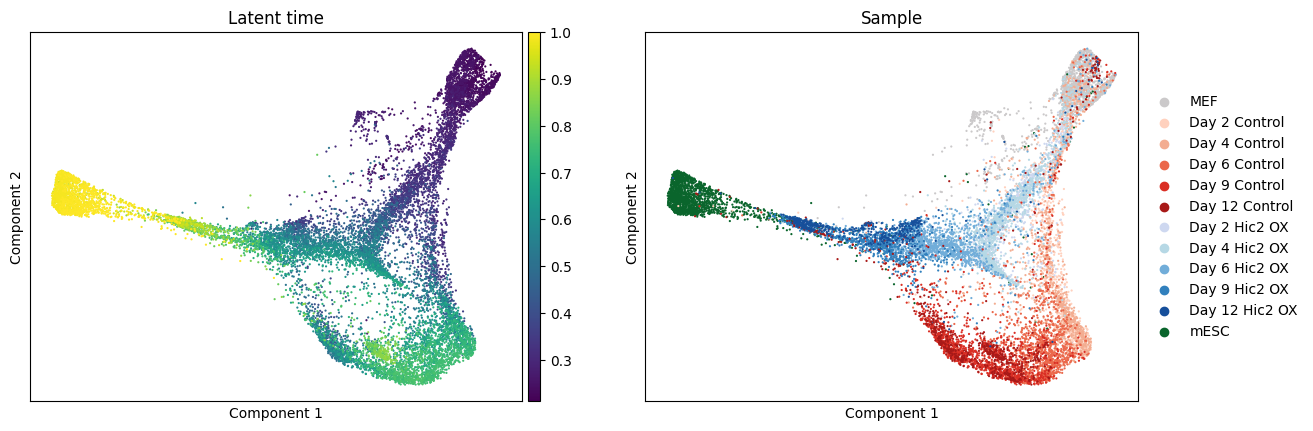

In [53]:
# Plot latent time
axis_list = scanpy.pl.embedding(basis='fdl', adata=adata, color=["latent_time", "sample"], size=10, title=["Latent time", "Sample"], show=False)
for axis in axis_list:
    axis.set_xlabel("Component 1")
    axis.set_ylabel("Component 2")
pyplot.show()

In [54]:
# Velocity cosine correlations
scvelo.tl.velocity_graph(adata, vkey="sde_velocity", n_jobs=16)

computing velocity graph (using 16/16 cores)


  0%|          | 0/12791 [00:00<?, ?cells/s]

/home/love/miniconda3/envs/velocity/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=11139) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:35) --> added 
    'sde_velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:01) --> added
    'sde_velocity_umap', embedded velocity vectors (adata.obsm)


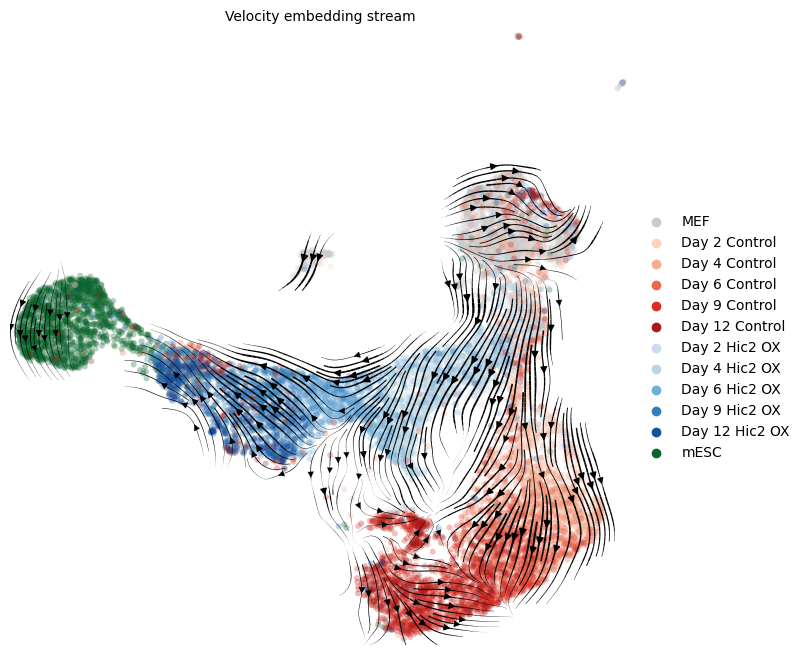

In [4]:
scvelo.pl.velocity_embedding_stream(adata, vkey="sde_velocity", basis="umap", color="sample", legend_loc="right", figsize=(8,8), title="Velocity embedding stream", density=4)

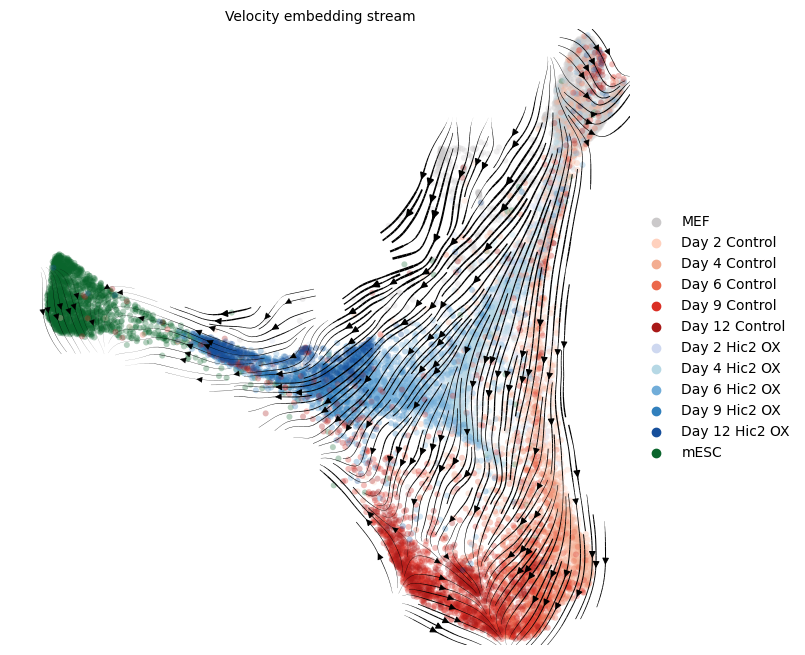

In [5]:
scvelo.pl.velocity_embedding_stream(adata, vkey="sde_velocity", basis="fdl", color="sample", legend_loc="right", figsize=(8,8), title="Velocity embedding stream", density=4)

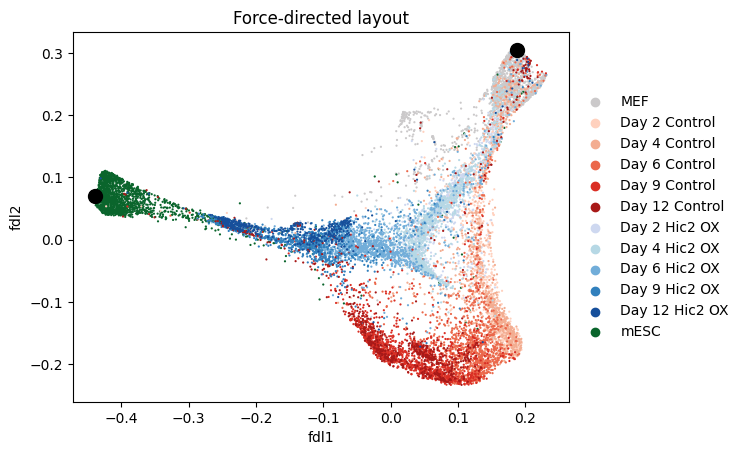

In [59]:
# Find good root and end cells

# Find root
root_filter = (adata.obs["group"]=="MEF")
# Use MEF cell with largest UMAP2, ignoring outliers with >10
root_index = numpy.argmax(adata[root_filter].obsm["X_fdl"][:,1])
root_barcode = adata[root_filter].obs.index[root_index]
adata.obs["manual_root"] = False
adata.obs["manual_root"].loc[root_barcode] = True

# Find end
end_filter = adata.obs["group"]=="mESC"
# Use mESC cell with smallest UMAP1
end_index = numpy.argmin(adata[end_filter].obsm["X_fdl"][:,0])
end_barcode = adata[end_filter].obs.index[end_index]
adata.obs["manual_end"] = False
adata.obs["manual_end"].loc[end_barcode] = True

ax = scanpy.pl.embedding(basis='fdl', adata=adata, color="sample", size=10, title="Force-directed layout", show=False)

# Plot UMAP
ax.scatter(*adata[adata.obs["manual_end"]].obsm["X_fdl"][0], marker="o", s=100, color="black")
ax.scatter(*adata[adata.obs["manual_root"]].obsm["X_fdl"][0], marker="o", s=100, color="black")
ax.yaxis.set_major_locator(matplotlib.ticker.AutoLocator())
ax.xaxis.set_major_locator(matplotlib.ticker.AutoLocator())

pyplot.show()

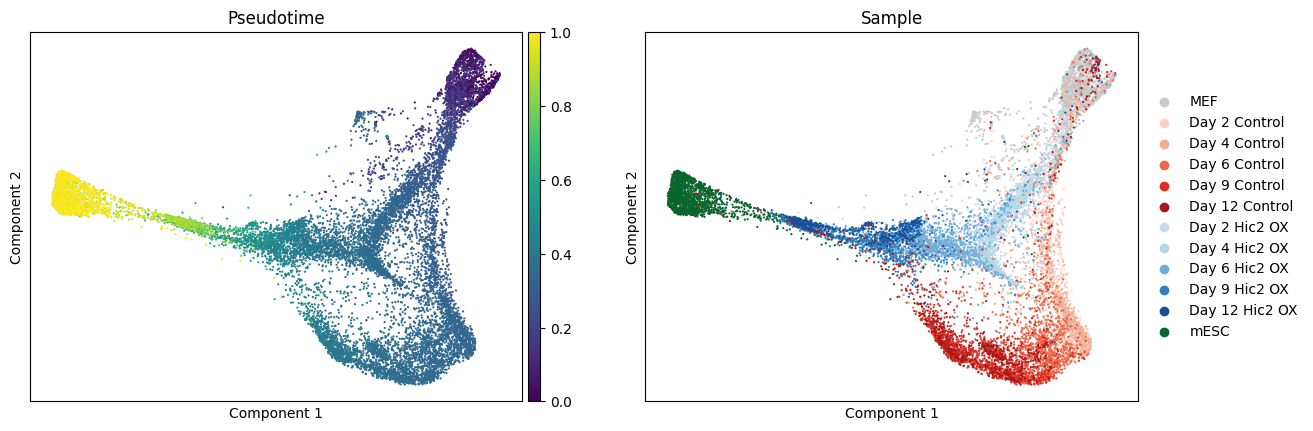

In [60]:
# Pseudotime
global_root_index = numpy.argmax(adata.obs.index == root_barcode)
global_end_index = numpy.argmax(adata.obs.index == end_barcode)

scvelo.tl.velocity_pseudotime(adata, root_key=global_root_index, end_key=global_end_index, vkey="sde_velocity")

# Plot velocities colored by latent time
axis_list = scanpy.pl.embedding(basis='fdl', adata=adata, color=["sde_velocity_pseudotime", "sample"], size=10, title=["Pseudotime", "Sample"], show=False)
for axis in axis_list:
    axis.set_xlabel("Component 1")
    axis.set_ylabel("Component 2")
pyplot.show()

In [74]:
# Calculate correlation between specific genes and latent time

def infer_gene_correlations(adata, significance_threshold=0.05):
    import pandas as pd
    from scipy.stats import pearsonr
    from statsmodels.stats.multitest import multipletests
    import numpy as np
    """
    Analyze correlations between gene expressions and latent time in an AnnData object.

    Parameters:
    adata (AnnData): An AnnData object containing latent time and gene expression data.
    significance_threshold (float): The threshold for statistical significance.

    Returns:
    AnnData: The input AnnData object with additional annotations for gene correlations.
    """
    # Ensure that the latent time is a numpy array and handle potential missing values
    latent_time = adata.obs['latent_time'].dropna().values

    # Handle potential missing values in gene expression data
    expression = adata.X.toarray()
    valid_indices = ~np.isnan(expression).any(axis=1) & ~np.isnan(latent_time)
    expression = expression[valid_indices]
    latent_time = latent_time[valid_indices]

    # Vectorized calculation of correlations and p-values
    correlations, p_values = zip(*[pearsonr(expression[:, j], latent_time) for j in range(expression.shape[1])])

    # Adding the results to the AnnData object
    adata.var['correlation'] = pd.Series(correlations, index=adata.var_names)
    adata.var['correlation_abs'] = pd.Series(np.abs(correlations), index=adata.var_names)
    adata.var['p_value'] = pd.Series(p_values, index=adata.var_names)

    # Applying Benjamini-Hochberg procedure
    p_adjusted = multipletests(p_values, method='fdr_bh')[1]
    adata.var['p_value_adj'] = pd.Series(p_adjusted, index=adata.var_names)

    # Sorting genes and dropping unnecessary columns
    genes_sorted = adata.var.sort_values(by='correlation_abs', ascending=False)

    # Filter out significant genes
    significant_genes = genes_sorted[genes_sorted['p_value_adj'] <= significance_threshold]
    
    return adata, significant_genes

adata, significant_genes = infer_gene_correlations(adata)
print(significant_genes.sort_values("correlation_abs", ascending=False)[:25][["correlation", "p_value", "p_value_adj"]])

            correlation  p_value  p_value_adj
gene_names                                   
Serpinh1      -0.825287      0.0          0.0
Cald1         -0.822928      0.0          0.0
Sparc         -0.820791      0.0          0.0
S100a6        -0.791418      0.0          0.0
S100a11       -0.783171      0.0          0.0
Timp2         -0.767936      0.0          0.0
Vim           -0.761484      0.0          0.0
Rhoc          -0.760560      0.0          0.0
Lgals1        -0.751720      0.0          0.0
Anxa1         -0.747365      0.0          0.0
Col1a1        -0.738395      0.0          0.0
Tpm1          -0.738020      0.0          0.0
Col5a2        -0.731201      0.0          0.0
Mkrn1          0.730856      0.0          0.0
Fstl1         -0.724914      0.0          0.0
Col1a2        -0.724761      0.0          0.0
Anxa2         -0.723549      0.0          0.0
Gpx8          -0.720711      0.0          0.0
Hsp90ab1       0.718924      0.0          0.0
Anxa5         -0.716138      0.0  

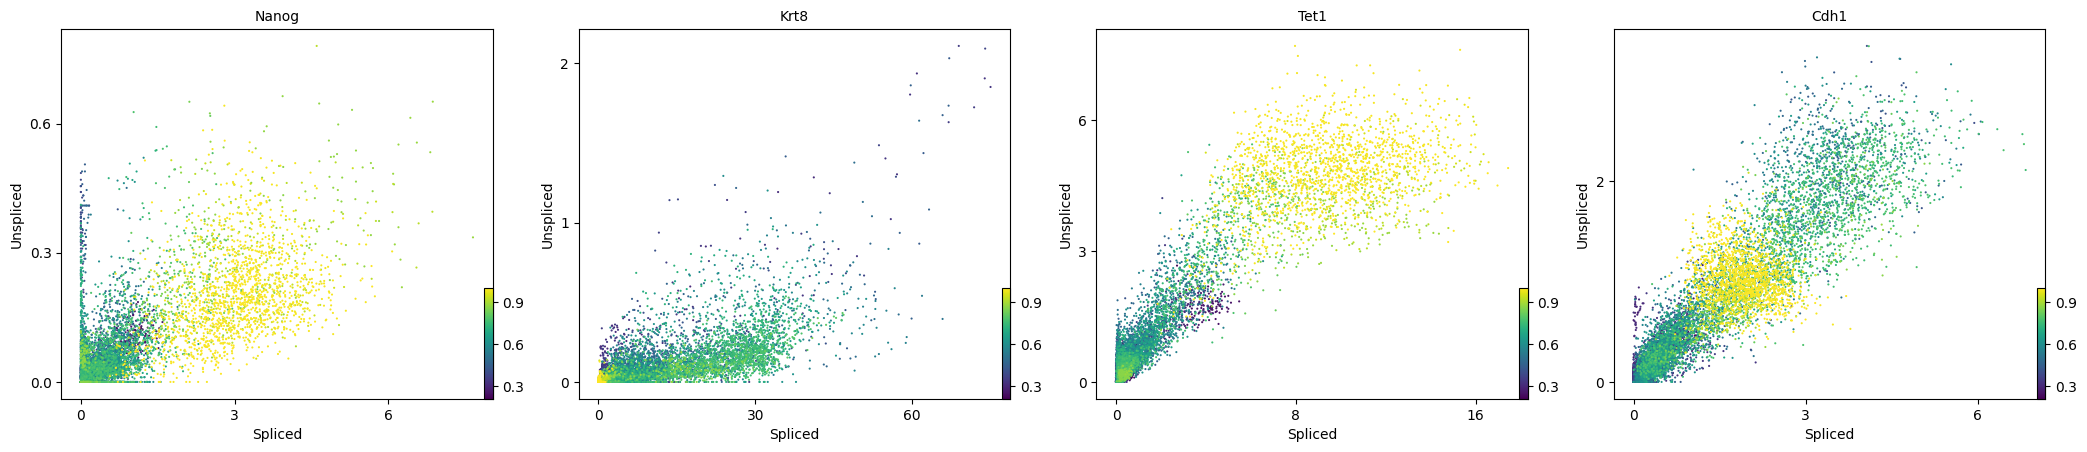

In [70]:
# Plot latent time for specific genes
genes_of_interest = ["Nanog", "Krt8", "Tet1", "Cdh1"]
scvelo.pl.scatter(adata, basis=genes_of_interest, color=["latent_time"], frameon=True, vkey="sde_velocity", xlabel="Spliced", ylabel="Unspliced")

In [ ]:
# Save adata object
adata.write_h5ad(
    working_directory+"/velocity_sdevelo.h5ad",
    compression=hdf5plugin.FILTERS["zstd"]
)